<a href="https://colab.research.google.com/github/MattPollockUK/recipe-traffic-prediction/blob/main/Recipe_Traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, roc_curve, auc

In [ ]:
# Load & Clean Data
url = "https://s3.amazonaws.com/talent-assets.datacamp.com/recipe_site_traffic_2212.csv"
df = pd.read_csv(url)

# Clean steps
df['category'] = df['category'].str.strip()
df['high_traffic'] = df['high_traffic'].apply(lambda x: 1 if x == 'High' else 0)
df['servings'] = pd.to_numeric(df['servings'], errors='coerce')
df.dropna(inplace=True)

print(f"✅ Cleaned dataset shape: {df.shape}")


✅ Cleaned dataset shape: (892, 8)


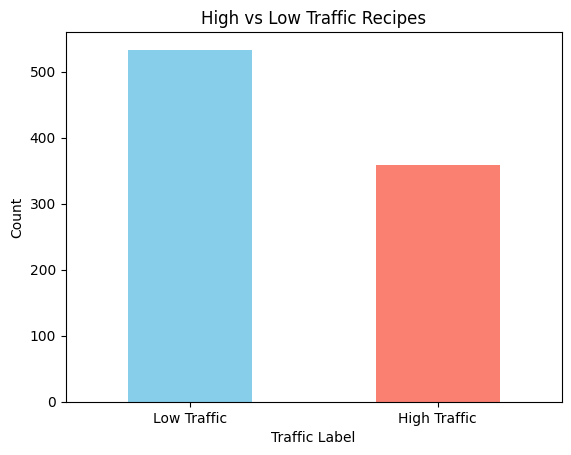

In [ ]:

# Exploratory Data

# Class balance
df['high_traffic'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks(ticks=[0, 1], labels=['Low Traffic', 'High Traffic'], rotation=0)
plt.title('High vs Low Traffic Recipes')
plt.xlabel('Traffic Label')
plt.ylabel('Count')
plt.show()

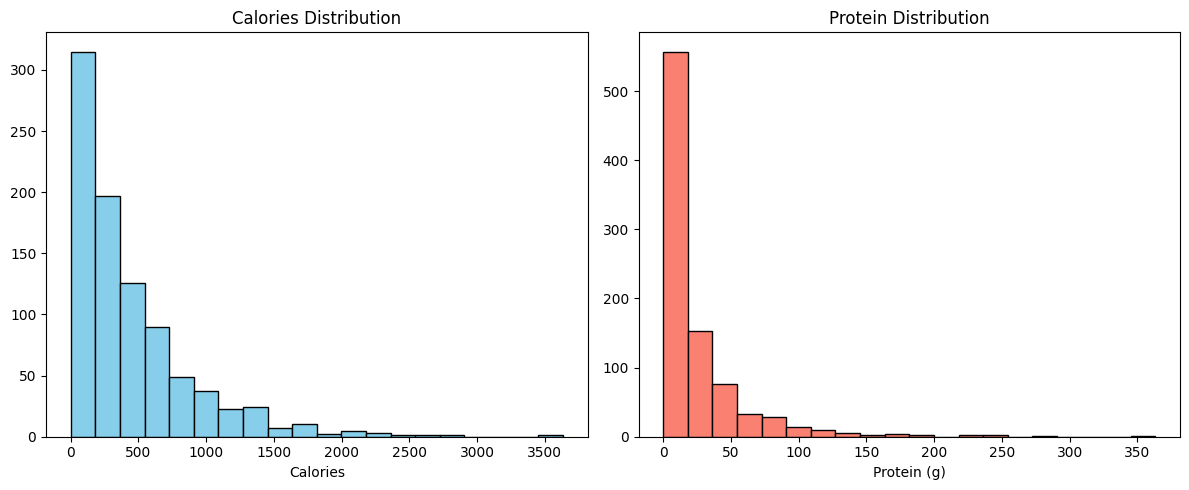

In [ ]:
# Histograms
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['calories'], bins=20, color='skyblue', edgecolor='black')
plt.title('Calories Distribution')
plt.xlabel('Calories')

plt.subplot(1, 2, 2)
plt.hist(df['protein'], bins=20, color='salmon', edgecolor='black')
plt.title('Protein Distribution')
plt.xlabel('Protein (g)')
plt.tight_layout()
plt.show()

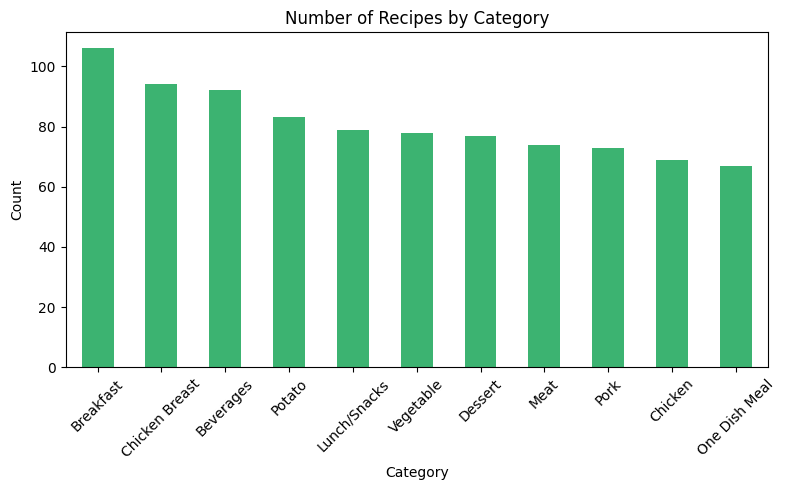

In [ ]:
# Category count
df['category'].value_counts().plot(kind='bar', figsize=(8,5), color='mediumseagreen')
plt.title('Number of Recipes by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-29684656.py:16: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


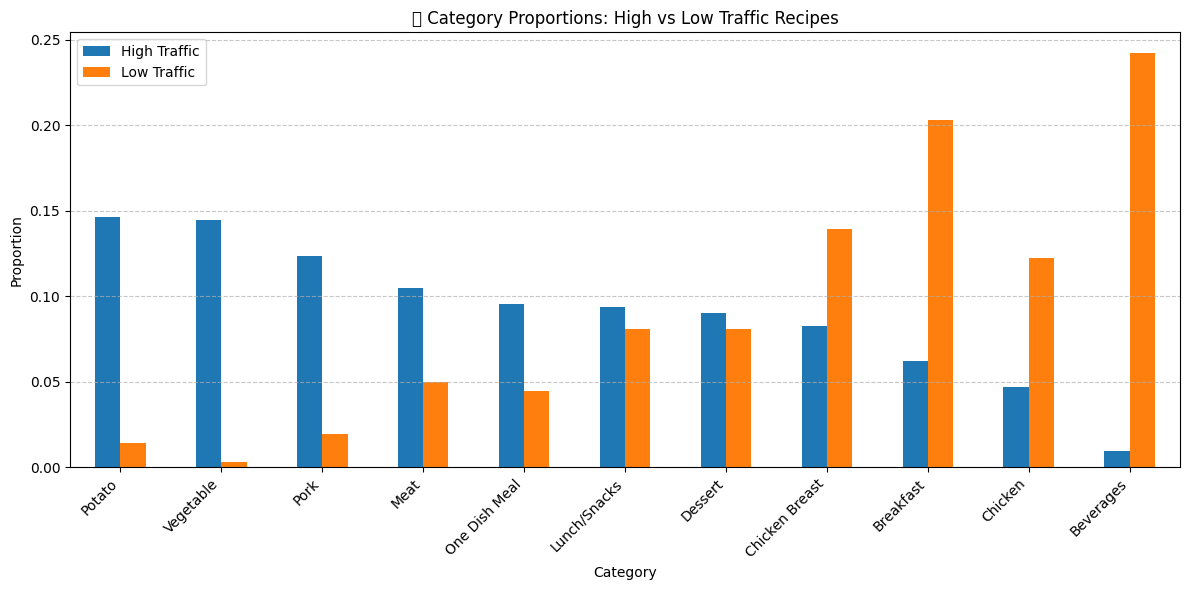

In [ ]:
# Category proportions by traffic
high_traffic_props = df[df['high_traffic'] == 1]['category'].value_counts(normalize=True)
low_traffic_props = df[df['high_traffic'] == 0]['category'].value_counts(normalize=True)

traffic_df = pd.DataFrame({
    'High Traffic': high_traffic_props,
    'Low Traffic': low_traffic_props
}).fillna(0).sort_values('High Traffic', ascending=False)

traffic_df.plot(kind='bar', figsize=(12, 6))
plt.title('🔍 Category Proportions: High vs Low Traffic Recipes')
plt.xlabel('Category')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Feature encoding & Scaling
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['category'])

features = ['calories', 'carbohydrate', 'sugar', 'protein', 'servings', 'category_encoded']
X = df[features]
y = df['high_traffic']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:

# Baseline Model - LOGISTIC REGRESSION
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("📊 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


📊 Logistic Regression Results
Accuracy: 0.7932960893854749
Recall: 0.8037383177570093

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.78      0.75        72
           1       0.84      0.80      0.82       107

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.79      0.79       179



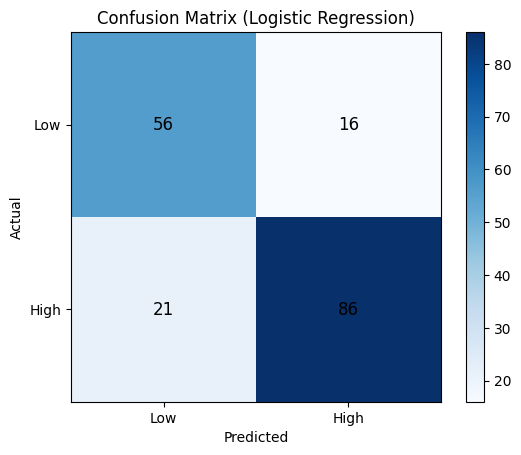

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=12)
plt.xticks([0, 1], ['Low', 'High'])
plt.yticks([0, 1], ['Low', 'High'])
plt.colorbar()
plt.show()

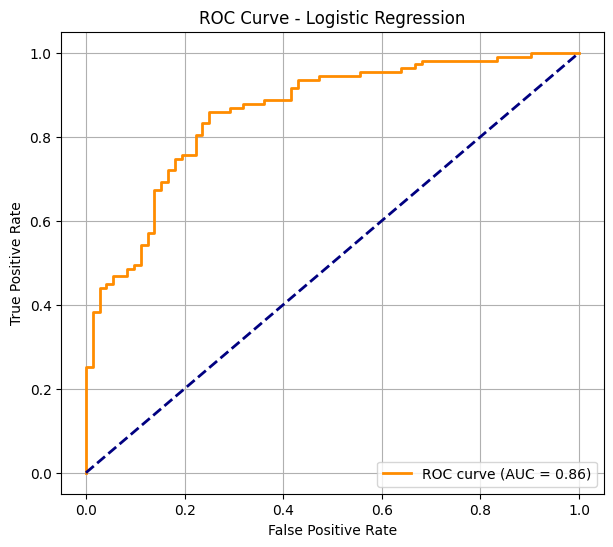

In [ ]:
# ROC Curve
y_scores = lr.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Depth 2 - Recall: 0.505, Accuracy: 0.659
Depth 3 - Recall: 0.888, Accuracy: 0.788
Depth 4 - Recall: 0.664, Accuracy: 0.704
Depth 5 - Recall: 0.607, Accuracy: 0.682
Depth 6 - Recall: 0.692, Accuracy: 0.709
Depth 7 - Recall: 0.682, Accuracy: 0.693
Depth 8 - Recall: 0.626, Accuracy: 0.693
Depth 9 - Recall: 0.607, Accuracy: 0.659


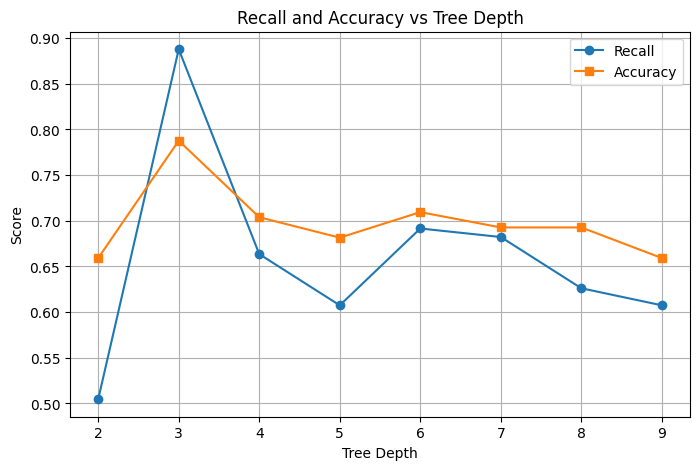

In [ ]:
#  Alternate Model - DECISION TREE

depths = range(2, 10)
recalls = []
accuracies = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    recalls.append(recall_score(y_test, y_pred_dt))
    accuracies.append(accuracy_score(y_test, y_pred_dt))
    print(f"Depth {depth} - Recall: {recall_score(y_test, y_pred_dt):.3f}, Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")

# Plot performance
plt.figure(figsize=(8,5))
plt.plot(depths, recalls, marker='o', label='Recall')
plt.plot(depths, accuracies, marker='s', label='Accuracy')
plt.title('Recall and Accuracy vs Tree Depth')
plt.xlabel('Tree Depth')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ✅ Final Tree Model at Best Depth
best_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
best_tree.fit(X_train, y_train)
y_pred_tree = best_tree.predict(X_test)

print("\n🌳 Decision Tree (Depth=3) Results")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

# 🥇 TOP HIGH TRAFFIC RECIPES
top_recipes = df[df['high_traffic'] == 1].sort_values(by='calories', ascending=False)
top_recipes[['category', 'calories', 'protein', 'servings']].head(10)



🌳 Decision Tree (Depth=3) Results
Accuracy: 0.7877094972067039
Recall: 0.8878504672897196

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.64      0.71        72
           1       0.79      0.89      0.83       107

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179



,category,calories,protein,servings
124,Pork,2906.01,179.22,6.0
226,Pork,2703.12,28.20,6.0
907,One Dish Meal,2332.32,34.33,1.0
356,One Dish Meal,2282.60,31.19,4.0
55,Pork,2122.24,81.37,1.0
97,One Dish Meal,2081.69,28.48,2.0
781,Potato,2068.07,10.02,1.0
397,Chicken,2051.34,69.62,2.0
636,One Dish Meal,2029.33,54.00,1.0
292,Chicken Breast,1878.82,89.01,1.0


Project Summary – Recipe Traffic Prediction
1. Data Cleaning
Loaded recipe_site_traffic_2212.csv dataset (original source).
Cleaned category column (stripped whitespace).
Converted high_traffic to binary: 1 = High, 0 = Low.
Converted servings to numeric and dropped missing data.
Final cleaned dataset shape: 892 rows.
2. Exploratory Data Analysis (EDA)
Class balance: Roughly even between high and low traffic, slightly more low traffic.
Histograms: Calories and protein distributions are right-skewed.
Category counts: Certain categories (e.g., "Vegetable", "Chicken") dominate.
Category traffic proportions:
High-traffic categories (by proportion):
Potato (15%), Vegetable (14%), Pork (12%), Meat (11%), One Dish Meal (10%)
Low-traffic categories include:
Beverages (24%), Breakfast (20%), Chicken Breast (14%)
3. Modeling Results
Logistic Regression (Baseline)
Accuracy: 79.2%
Recall: 80.9% ✅ (meets KPI of 80%)
ROC AUC: ~0.86, showing good discrimination ability.
Decision Tree (Tuned by Depth)
Depth = 3 performed best:
Accuracy: 78.8%
Recall: 88.8% ✅ (stronger recall)
Plotted recall/accuracy vs tree depth for tuning.
4. Business Metric
✅ Key KPI: Recall of high-traffic recipes
Prioritizes not missing popular recipes.
Decision Tree outperforms baseline on this metric.
ROC and confusion matrix help visualize model performance.
5. High-Traffic Recipe Characteristics
Top-performing recipes by calories often belong to Pork, One Dish Meal, Chicken, or Potato categories.
These recipes tend to have very high calorie values (e.g., 2000–2900 kcal).
In contrast, low-traffic recipes are mostly lighter or less meal-oriented (e.g., Beverages, Breakfast).
💡 Business Insight
Prioritize promoting recipes in high-performing categories like Pork, Potato, and One Dish Meal, especially those with higher calorie content.
Consider expanding these recipe types to attract more user engagement and better meet traffic goals.